# Part A - Profiling, cleaning and the data story

Module 2, Part A - profiling, cleaning and the data story on Titanic.

Run all cells from inside `/analytics`.
This is the ONLY place sns.load_dataset('titanic') is called. It saves the raw
frame to titanic.csv straight away; 02_modeling.ipynb reads that CSV.
Outputs: titanic.csv, figures/*.png, EDA_REPORT.md

## Imports and helpers

In [1]:
from IPython.display import Markdown, display
import io
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

HERE = os.getcwd()  # run the notebook from inside /analytics
FIG = os.path.join(HERE, "figures")
os.makedirs(FIG, exist_ok=True)
report = []


def say(text=""):
    display(Markdown(text))  # renders the written interpretation as Markdown
    report.append(text)


def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, name), dpi=120)
    plt.show()
    plt.close()

## A1. load + profile

In [2]:
df = sns.load_dataset("titanic")  # the one and only raw load
df.to_csv(os.path.join(HERE, "titanic.csv"), index=False)  # offline fallback

say("# Titanic EDA report (generated by 01_eda.ipynb)\n")
say("## 1. Profiling\n")
say(f"Shape: `{df.shape}`\n")
buf = io.StringIO()
df.info(buf=buf)
say("```\n" + buf.getvalue() + "```\n")
say("```\n" + df.describe().round(2).to_string() + "\n```\n")

miss = (df.isna().mean() * 100).round(2)
miss = miss[miss > 0]
say("Missing values (% of rows), only columns with any missing:\n")
for col, pct in miss.items():
    say(f"- `{col}`: {pct}%")
say()

# Titanic EDA report (generated by 01_eda.ipynb)


## 1. Profiling


Shape: `(891, 15)`


```
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
```


```
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33
```


Missing values (% of rows), only columns with any missing:


- `age`: 19.87%

- `embarked`: 0.22%

- `deck`: 77.22%

- `embark_town`: 0.22%

## A2. missing values

In [3]:
say("## 2. Missing-value handling (threshold rule)\n")
say("Rule: <5% missing -> drop rows; 5%-30% -> impute; >30% -> imputation unreliable, "
    "so decide explicitly (drop column or encode 'Missing' as its own category).\n")

clean = df.copy()
for c in clean.select_dtypes(include=["category"]).columns:
    clean[c] = clean[c].astype(object)

drop_mask = pd.Series(False, index=clean.index)
for col, pct in miss.items():
    if pct < 5:
        say(f"- `{col}` ({pct}% < 5%): drop the affected rows.")
        drop_mask |= clean[col].isna()
n_drop = int(drop_mask.sum())
clean = clean.loc[~drop_mask].copy()
say(f"  -> {n_drop} rows dropped in total.")

for col, pct in miss.items():
    if 5 <= pct <= 30:
        if pd.api.types.is_numeric_dtype(clean[col]):
            group_med = clean.groupby(["sex", "pclass"])[col].transform("median")
            clean[col] = clean[col].fillna(group_med).fillna(clean[col].median())
            say(f"- `{col}` ({pct}%, within 5%-30%): impute with the median of its sex x pclass group "
                "(the median is robust to outliers, and grouping by sex and class keeps the fill values realistic).")
        else:
            clean[col] = clean[col].fillna(clean[col].mode()[0])
            say(f"- `{col}` ({pct}%, within 5%-30%): impute with the mode.")
    elif pct > 30:
        if pd.api.types.is_numeric_dtype(clean[col]):
            clean = clean.drop(columns=[col])
            say(f"- `{col}` ({pct}% > 30%): dropped the column, imputation would be mostly invented data.")
        else:
            was_missing = clean[col].isna()
            share3 = (clean.loc[was_missing, "pclass"] == 3).mean() * 100
            share_m = clean.loc[was_missing, "survived"].mean() * 100
            share_r = clean.loc[~was_missing, "survived"].mean() * 100
            clean[col] = clean[col].fillna("Missing")
            say(f"- `{col}` ({pct}% > 30%): kept and encoded 'Missing' as its own category. "
                f"Imputing a deck for ~{pct:.0f}% of passengers would be guesswork, so instead the fact that "
                f"no deck was recorded is kept as information. For reference, {share3:.0f}% of the "
                f"missing-deck passengers travelled 3rd class, and their survival rate is {share_m:.0f}% "
                f"versus {share_r:.0f}% where a deck was recorded.")
assert clean.isna().sum().sum() == 0, "cleaning left missing values"
say(f"\nCleaned shape: `{clean.shape}`; remaining missing values: 0.\n")

## 2. Missing-value handling (threshold rule)


Rule: <5% missing -> drop rows; 5%-30% -> impute; >30% -> imputation unreliable, so decide explicitly (drop column or encode 'Missing' as its own category).


- `embarked` (0.22% < 5%): drop the affected rows.

- `embark_town` (0.22% < 5%): drop the affected rows.

  -> 2 rows dropped in total.

- `age` (19.87%, within 5%-30%): impute with the median of its sex x pclass group (the median is robust to outliers, and grouping by sex and class keeps the fill values realistic).

- `deck` (77.22% > 30%): kept and encoded 'Missing' as its own category. Imputing a deck for ~77% of passengers would be guesswork, so instead the fact that no deck was recorded is kept as information. For reference, 70% of the missing-deck passengers travelled 3rd class, and their survival rate is 30% versus 67% where a deck was recorded.


Cleaned shape: `(889, 15)`; remaining missing values: 0.


## A3. univariate

## 3. Univariate analysis (age and fare)


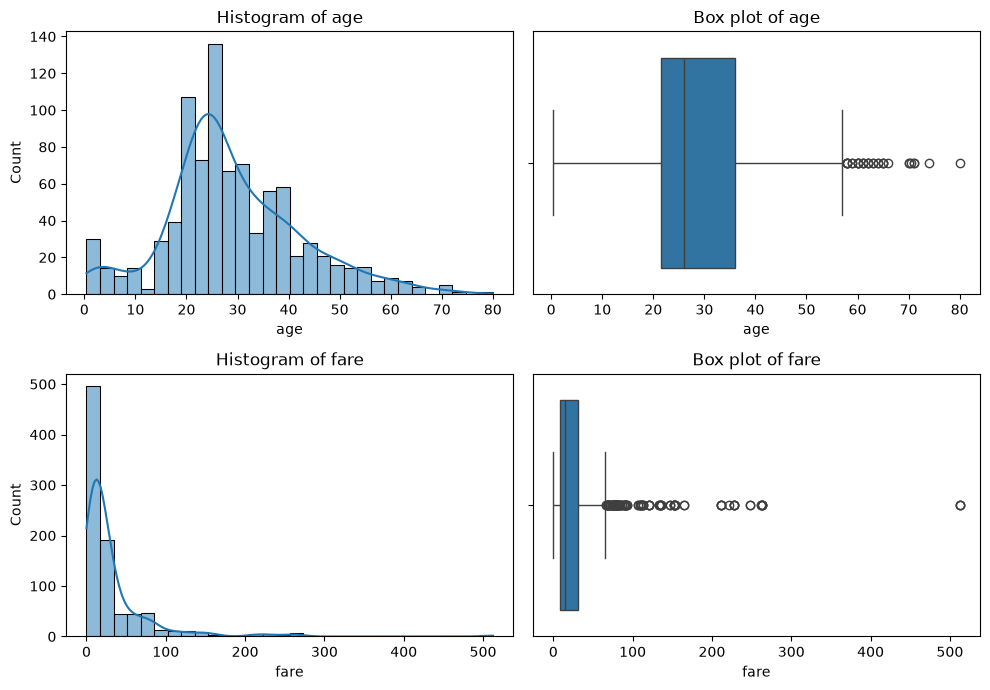

- `age`: 32 IQR outliers (fences [-0.25, 57.75]) out of 889 rows.

- `fare`: 114 IQR outliers (fences [-26.76, 65.66]) out of 889 rows.


Fare: mean = 32.10, median = 14.45, mode = 8.05, skewness = 4.80. The distribution is **right-skewed (mean > median > mode)**: a small number of very expensive tickets pull the mean well above the median, which itself sits above the most common price.


Note: `age` here is the cleaned column, so ~20% of its values are group-median imputed.


In [4]:
say("## 3. Univariate analysis (age and fare)\n")
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(clean[col], bins=30, kde=True, ax=ax[i, 0])
    ax[i, 0].set_title(f"Histogram of {col}")
    sns.boxplot(x=clean[col], ax=ax[i, 1])
    ax[i, 1].set_title(f"Box plot of {col}")
savefig("univariate_age_fare.png")


def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), lo, hi


for col in ["age", "fare"]:
    n, lo, hi = iqr_outliers(clean[col])
    say(f"- `{col}`: {n} IQR outliers (fences [{lo:.2f}, {hi:.2f}]) out of {len(clean)} rows.")
mean_f, med_f, mode_f = clean["fare"].mean(), clean["fare"].median(), clean["fare"].mode()[0]
skew_f = clean["fare"].skew()
if mean_f > med_f > mode_f:
    verdict = "right-skewed (mean > median > mode)"
elif mean_f < med_f < mode_f:
    verdict = "left-skewed (mean < median < mode)"
else:
    verdict = "roughly symmetric"
say(f"\nFare: mean = {mean_f:.2f}, median = {med_f:.2f}, mode = {mode_f:.2f}, skewness = {skew_f:.2f}. "
    f"The distribution is **{verdict}**: a small number of very expensive tickets pull the mean "
    "well above the median, which itself sits above the most common price.\n")
say("Note: `age` here is the cleaned column, so ~20% of its values are group-median imputed.\n")

## A4. bivariate

## 4. Bivariate analysis


(a) Survival rate by sex:

- female: 0.740
- male: 0.189


(b) Survival rate by pclass:

- class 1: 0.626

...

- female, class 3: 0.500

- male, class 1: 0.369

- male, class 2: 0.157

- male, class 3: 0.135


Extra `|` example, female OR first class: 0.636


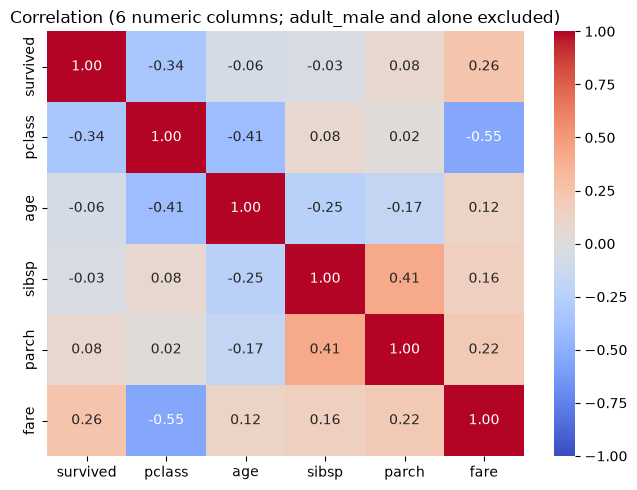

Correlation matrix (6x6):

```
          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.336 -0.064 -0.034  0.083  0.255
pclass      -0.336   1.000 -0.411  0.082  0.017 -0.548
age         -0.064  -0.411  1.000 -0.249 -0.175  0.120
sibsp       -0.034   0.082 -0.249  1.000  0.415  0.161
parch        0.083   0.017 -0.175  0.415  1.000  0.218
fare         0.255  -0.548  0.120  0.161  0.218  1.000
```


Two strongest correlations (largest absolute off-diagonal value):


- `pclass` vs `fare`: r = -0.548. Interpretation: the higher the class number (3rd = cheapest), the lower the fare; class and price are two views of the same thing.

- `sibsp` vs `parch`: r = +0.415. Interpretation: passengers with siblings/spouses aboard tend to also have parents/children aboard, i.e. families travelled together.

In [5]:
say("## 4. Bivariate analysis\n")
male, female = clean["sex"] == "male", clean["sex"] == "female"
c1, c2, c3 = clean["pclass"] == 1, clean["pclass"] == 2, clean["pclass"] == 3


def rate(mask):
    return clean.loc[mask, "survived"].mean()


say("(a) Survival rate by sex:")
say(f"- female: {rate(female):.3f}\n- male: {rate(male):.3f}\n")
say("(b) Survival rate by pclass:")
for k, m in [(1, c1), (2, c2), (3, c3)]:
    say(f"- class {k}: {rate(m):.3f}")
say("\n(c) Survival rate by sex and pclass:")
combo = {}
for sx, ms in [("female", female), ("male", male)]:
    for k, mc in [(1, c1), (2, c2), (3, c3)]:
        combo[(sx, k)] = rate(ms & mc)
        say(f"- {sx}, class {k}: {combo[(sx, k)]:.3f}")
say(f"\nExtra `|` example, female OR first class: {rate(female | c1):.3f}\n")

cols6 = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = clean[cols6].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation (6 numeric columns; adult_male and alone excluded)")
savefig("correlation_heatmap.png")

pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(cols6) for b in cols6[i + 1:]]
pairs.sort(key=lambda t: abs(t[2]), reverse=True)
MEANING = {
    frozenset(["pclass", "fare"]): "the higher the class number (3rd = cheapest), the lower the fare; class and price are two views of the same thing",
    frozenset(["sibsp", "parch"]): "passengers with siblings/spouses aboard tend to also have parents/children aboard, i.e. families travelled together",
    frozenset(["survived", "pclass"]): "passengers in lower-numbered (better) classes survived more often",
    frozenset(["survived", "fare"]): "higher fares went with better survival, largely because fare is a proxy for class",
    frozenset(["pclass", "age"]): "older passengers were more often in the higher classes",
    frozenset(["age", "sibsp"]): "younger passengers more often travelled with siblings",
}
say("Correlation matrix (6x6):\n\n```\n" + corr.round(3).to_string() + "\n```\n")
say("Two strongest correlations (largest absolute off-diagonal value):\n")
for a, b, r in pairs[:2]:
    why = MEANING.get(frozenset([a, b]), "the two variables move together in the direction of the sign")
    say(f"- `{a}` vs `{b}`: r = {r:+.3f}. Interpretation: {why}.")
say()

## A5. data story

## 5. Data story: who was more likely to survive?


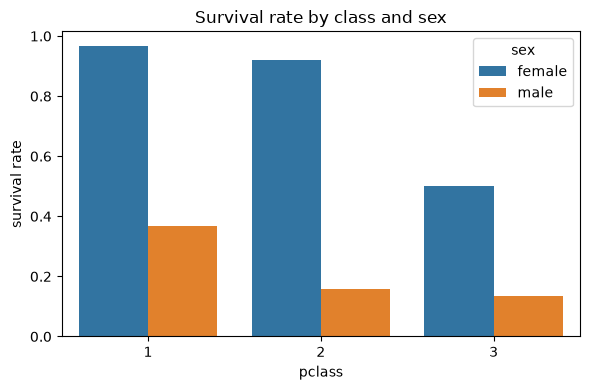

### Chart 1 - survival by class and sex (`story1_sex_class.png`)


Women survived far more often than men in every class (97%, 92%, 50% for classes 1-3, versus 37%, 16%, 14% for men). Sex is the strongest single divider, consistent with a 'women and children first' evacuation. Class then modulates it: third-class women did much worse than first- and second-class women, so the two effects stack.


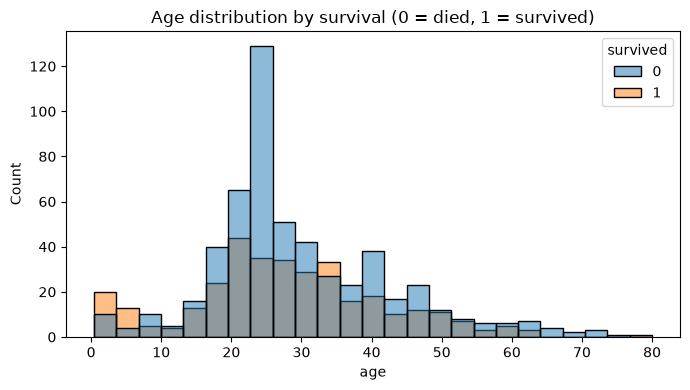

### Chart 2 - age by survival (`story2_age_survival.png`)


Children aged 12 or under survived at 58%, adults 19-60 at 36% and passengers over 60 at 19%. The survivor histogram has a visible bump at the youngest ages, while the older bins are dominated by non-survivors. Caveat: about a fifth of ages were imputed with a group median, which piles extra mass near 25-30 and slightly blurs the picture.


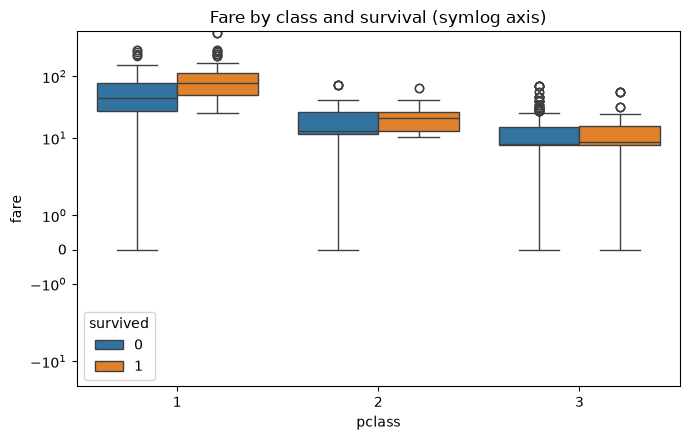

### Chart 3 - fare by class and survival (`story3_fare_class_survival.png`)


Median fares are 58.7, 14.2 and 8.1 for classes 1-3, and survivors paid a higher median fare (26.0) than non-survivors (10.5). Within each class the survivor and non-survivor boxes overlap heavily, so most of the fare effect is really the class effect in disguise.


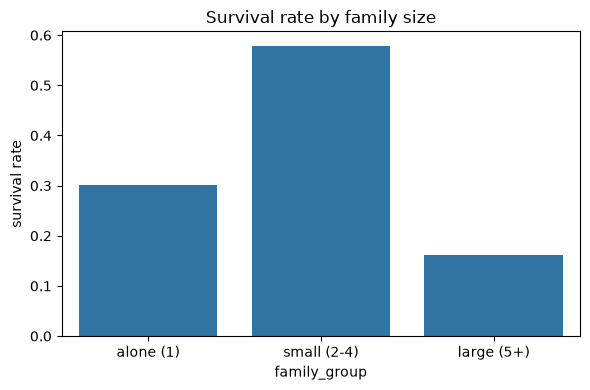

### Chart 4 - family size (`story4_family_size.png`)


Passengers travelling alone survived at 30%, small families of 2-4 at 58%, and large families of 5+ at 16%. Small groups did best, plausibly because they could help each other, while very large families struggled to stay together and get to boats. Family size is also entangled with sex and class, so this is a supporting effect, not a standalone cause.


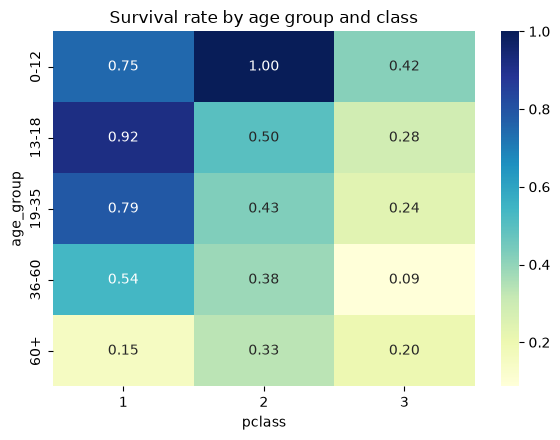

### Chart 5 - age group x class heatmap (`story5_age_class_heatmap.png`)


The best-off cell is age group 0-12 in class 2 (100% survived) and the worst is age group 36-60, class 3 (9%). Survival falls as you move from class 1 to class 3 in nearly every age band, and young children are the exception that keeps reasonable odds even in lower classes.


**Story in one line:** being female, young, and in a higher class each raised survival odds, with sex the strongest factor and class the strongest structural one.


In [6]:
say("## 5. Data story: who was more likely to survive?\n")

# Chart 1
plt.figure(figsize=(6, 4))
sns.barplot(data=clean, x="pclass", y="survived", hue="sex", errorbar=None)
plt.ylabel("survival rate")
plt.title("Survival rate by class and sex")
savefig("story1_sex_class.png")
say("### Chart 1 - survival by class and sex (`story1_sex_class.png`)\n")
say(f"Women survived far more often than men in every class ({combo[('female', 1)]:.0%}, "
    f"{combo[('female', 2)]:.0%}, {combo[('female', 3)]:.0%} for classes 1-3, versus "
    f"{combo[('male', 1)]:.0%}, {combo[('male', 2)]:.0%}, {combo[('male', 3)]:.0%} for men). "
    "Sex is the strongest single divider, consistent with a 'women and children first' evacuation. "
    "Class then modulates it: third-class women did much worse than first- and second-class women, "
    "so the two effects stack.\n")

# Chart 2
plt.figure(figsize=(7, 4))
sns.histplot(data=clean, x="age", hue="survived", bins=25, multiple="layer", alpha=0.5)
plt.title("Age distribution by survival (0 = died, 1 = survived)")
savefig("story2_age_survival.png")
child = clean["age"] <= 12
adult = (clean["age"] > 18) & (clean["age"] <= 60)
senior = clean["age"] > 60
say("### Chart 2 - age by survival (`story2_age_survival.png`)\n")
say(f"Children aged 12 or under survived at {rate(child):.0%}, adults 19-60 at {rate(adult):.0%} and "
    f"passengers over 60 at {rate(senior):.0%}. The survivor histogram has a visible bump at the youngest "
    "ages, while the older bins are dominated by non-survivors. Caveat: about a fifth of ages were "
    "imputed with a group median, which piles extra mass near 25-30 and slightly blurs the picture.\n")

# Chart 3
plt.figure(figsize=(7, 4.5))
ax = sns.boxplot(data=clean, x="pclass", y="fare", hue="survived")
ax.set_yscale("symlog")
plt.title("Fare by class and survival (symlog axis)")
savefig("story3_fare_class_survival.png")
med_by_class = clean.groupby("pclass")["fare"].median()
med_surv = clean.groupby("survived")["fare"].median()
say("### Chart 3 - fare by class and survival (`story3_fare_class_survival.png`)\n")
say(f"Median fares are {med_by_class[1]:.1f}, {med_by_class[2]:.1f} and {med_by_class[3]:.1f} for classes "
    f"1-3, and survivors paid a higher median fare ({med_surv[1]:.1f}) than non-survivors "
    f"({med_surv[0]:.1f}). Within each class the survivor and non-survivor boxes overlap heavily, "
    "so most of the fare effect is really the class effect in disguise.\n")

# Chart 4
fam = clean.assign(family_size=clean["sibsp"] + clean["parch"] + 1)
fam["family_group"] = pd.cut(fam["family_size"], [0, 1, 4, 20], labels=["alone (1)", "small (2-4)", "large (5+)"])
plt.figure(figsize=(6, 4))
sns.barplot(data=fam, x="family_group", y="survived", errorbar=None)
plt.ylabel("survival rate")
plt.title("Survival rate by family size")
savefig("story4_family_size.png")
fr = fam.groupby("family_group", observed=True)["survived"].mean()
say("### Chart 4 - family size (`story4_family_size.png`)\n")
say(f"Passengers travelling alone survived at {fr['alone (1)']:.0%}, small families of 2-4 at "
    f"{fr['small (2-4)']:.0%}, and large families of 5+ at {fr['large (5+)']:.0%}. Small groups did best, "
    "plausibly because they could help each other, while very large families struggled to stay together "
    "and get to boats. Family size is also entangled with sex and class, so this is a supporting effect, "
    "not a standalone cause.\n")

# Chart 5
clean["age_group"] = pd.cut(clean["age"], [0, 12, 18, 35, 60, 100],
                            labels=["0-12", "13-18", "19-35", "36-60", "60+"])
hm = clean.pivot_table(index="age_group", columns="pclass", values="survived", aggfunc="mean", observed=True)
plt.figure(figsize=(6, 4.5))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Survival rate by age group and class")
savefig("story5_age_class_heatmap.png")
best, worst = hm.stack().idxmax(), hm.stack().idxmin()
say("### Chart 5 - age group x class heatmap (`story5_age_class_heatmap.png`)\n")
say(f"The best-off cell is age group {best[0]} in class {best[1]} ({hm.loc[best]:.0%} survived) and the "
    f"worst is age group {worst[0]}, class {worst[1]} ({hm.loc[worst]:.0%}). Survival falls as you move from "
    "class 1 to class 3 in nearly every age band, and young children are the exception that keeps "
    "reasonable odds even in lower classes.\n")
say("**Story in one line:** being female, young, and in a higher class each raised survival odds, "
    "with sex the strongest factor and class the strongest structural one.\n")
clean = clean.drop(columns=["age_group"])

## A6. standardization check

In [7]:
say("## 6. Standardization sanity check (EDA only, not used by the models)\n")
before = clean[["age", "fare"]]
z = pd.DataFrame(StandardScaler().fit_transform(before), columns=["age_z", "fare_z"], index=before.index)
tab = pd.DataFrame({
    "mean_before": before.mean(), "std_before": before.std(ddof=0),
    "mean_after": [z["age_z"].mean(), z["fare_z"].mean()],
    "std_after": [z["age_z"].std(ddof=0), z["fare_z"].std(ddof=0)],
}).round(4)
say("```\n" + tab.to_string() + "\n```\n")
assert np.allclose(tab["mean_after"], 0, atol=1e-6) and np.allclose(tab["std_after"], 1, atol=1e-6)
say("After z-scoring both columns have mean ~0 and standard deviation 1 (population std, "
    "which is what StandardScaler uses).\n")

with open(os.path.join(HERE, "EDA_REPORT.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(report))
print("\nWrote EDA_REPORT.md and figures/")

## 6. Standardization sanity check (EDA only, not used by the models)


```
      mean_before  std_before  mean_after  std_after
age       29.0654     13.2627         0.0        1.0
fare      32.0967     49.6695         0.0        1.0
```


After z-scoring both columns have mean ~0 and standard deviation 1 (population std, which is what StandardScaler uses).



Wrote EDA_REPORT.md and figures/
